<a href="https://colab.research.google.com/github/soup511/ML/blob/main/ML1_ipy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [88]:
import pandas as pd
data= pd.read_csv('/content/insurance.csv')

In [89]:
data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [5]:
data.shape

(1338, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

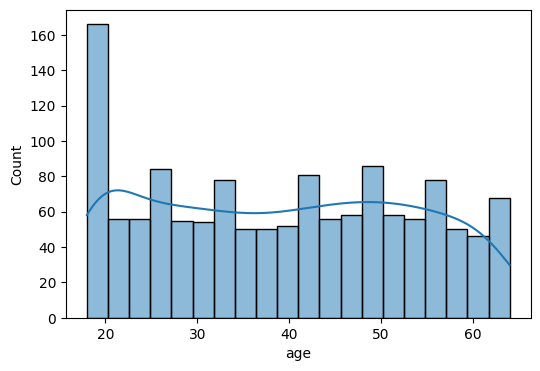

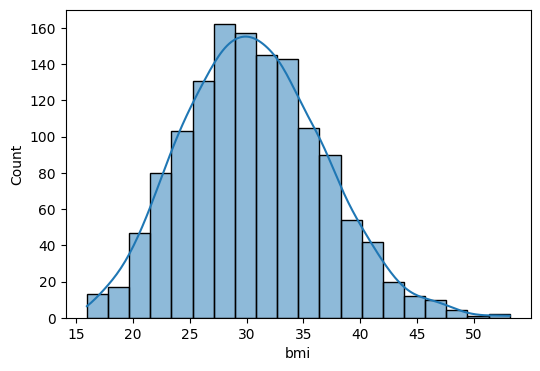

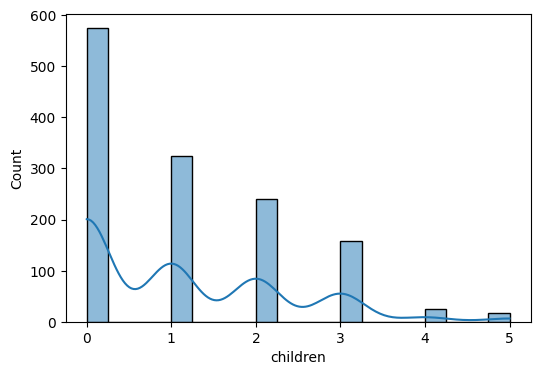

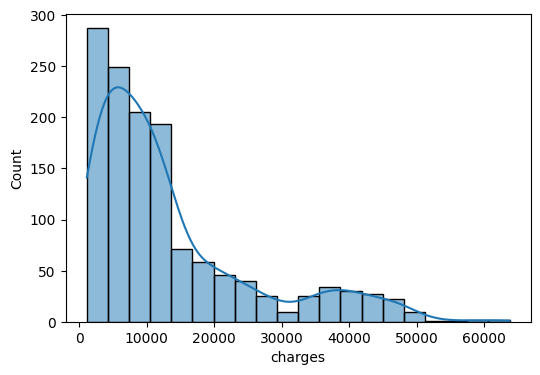

In [9]:
numaric_columns=['age', 'bmi', 'children','charges']
for col in numaric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(data[col],kde=True,bins=20)

<Axes: xlabel='sex', ylabel='count'>

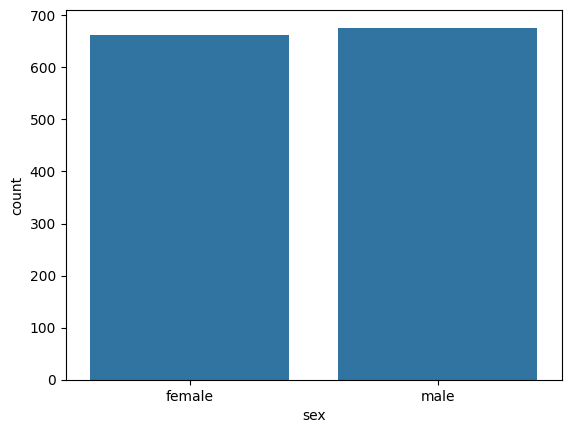

In [ ]:
sns.countplot(x=data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

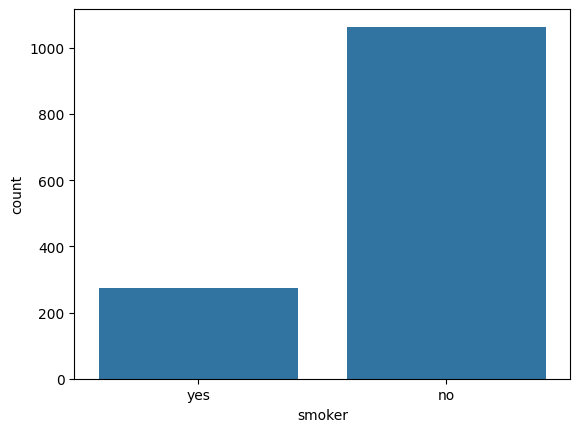

In [ ]:
sns.countplot(x=data['smoker'])

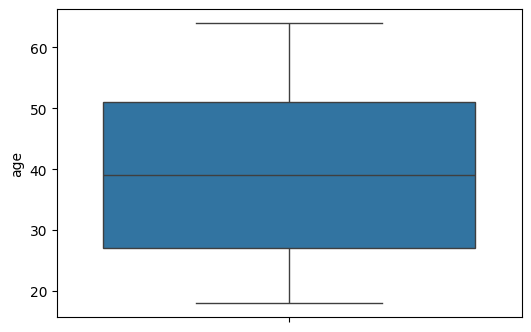

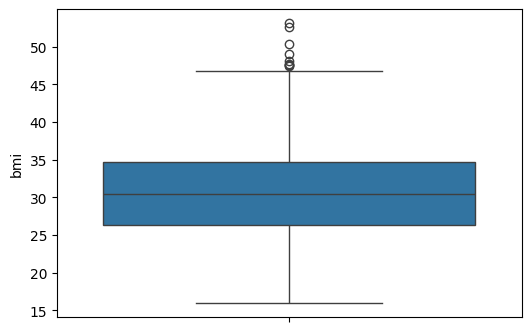

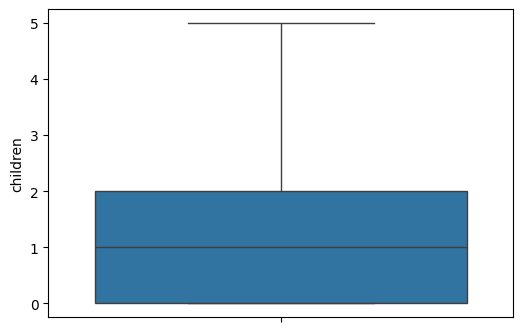

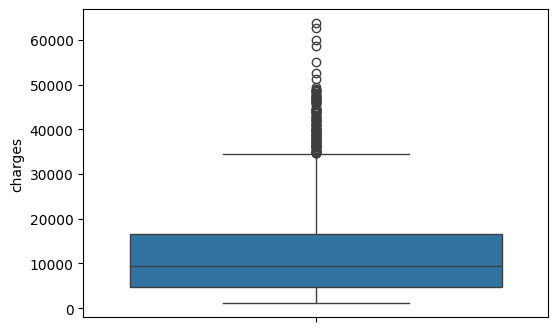

In [10]:
for col in numaric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(data[col])

<Axes: >

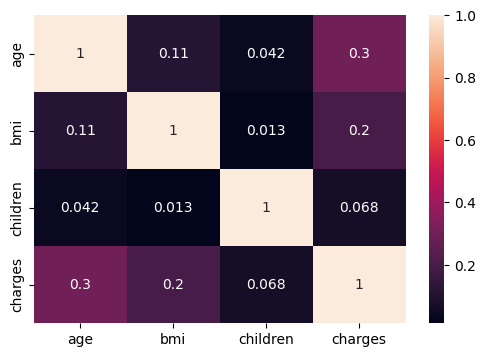

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True),annot=True)

data cleaning and processing

In [90]:
df=data.copy()

In [91]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [32]:
df.shape

(1337, 9)

In [73]:
df.drop_duplicates(inplace=True)

In [33]:
df.shape

(1337, 9)

In [92]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [34]:
df.dtypes

,0
age,int64
sex,int64
bmi,category
children,int64
smoker,int64
charges,int64
region_northwest,int64
region_southeast,int64
region_southwest,int64


In [93]:
df['sex'].value_counts()

,count
sex,
male,676
female,662


In [94]:
df['sex']=df['sex'].map({'male':0,'female':1})

In [37]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,NaN,overweight,0,0,16884,0,0,1
1,18,NaN,obese,1,1,1725,0,1,0
2,28,NaN,obese,3,1,4449,0,1,0
3,33,NaN,healthy,0,1,21984,1,0,0
4,32,NaN,overweight,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,NaN,obese,3,1,10600,1,0,0
1334,18,NaN,obese,0,1,2205,0,0,0
1335,18,NaN,obese,0,1,1629,0,1,0
1336,21,NaN,overweight,0,1,2007,0,0,1


In [75]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [95]:
df['smoker']=df['smoker'].map({'yes':0,'no':1})

In [40]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,NaN,overweight,0,NaN,16884,0,0,1
1,18,NaN,obese,1,NaN,1725,0,1,0
2,28,NaN,obese,3,NaN,4449,0,1,0
3,33,NaN,healthy,0,NaN,21984,1,0,0
4,32,NaN,overweight,0,NaN,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,NaN,obese,3,NaN,10600,1,0,0
1334,18,NaN,obese,0,NaN,2205,0,0,0
1335,18,NaN,obese,0,NaN,1629,0,1,0
1336,21,NaN,overweight,0,NaN,2007,0,0,1


In [77]:
data['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [96]:
df=pd.get_dummies(df,columns=['region'],drop_first=True)

In [103]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,overweight,0,0,16884,0,0,1
1,18,0,obese,1,1,1725,0,1,0
2,28,0,obese,3,1,4449,0,1,0
3,33,0,healthy,0,1,21984,1,0,0
4,32,0,overweight,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,obese,3,1,10600,1,0,0
1334,18,1,obese,0,1,2205,0,0,0
1335,18,1,obese,0,1,1629,0,1,0
1336,21,1,overweight,0,1,2007,0,0,1


In [113]:
#df=df.astype(int)

feature engineering and extration

In [105]:
df['bmi'] = data.loc[df.index, 'bmi'].astype(int)
df['bmi']=pd.cut(
    df['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','healthy','overweight','obese']
    )

In [106]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,overweight,0,0,16884,0,0,1
1,18,0,obese,1,1,1725,0,1,0
2,28,0,obese,3,1,4449,0,1,0
3,33,0,healthy,0,1,21984,1,0,0
4,32,0,overweight,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,obese,3,1,10600,1,0,0
1334,18,1,obese,0,1,2205,0,0,0
1335,18,1,obese,0,1,1629,0,1,0
1336,21,1,overweight,0,1,2007,0,0,1


In [107]:
df=pd.get_dummies(df,columns=['bmi'],drop_first=True)

In [108]:
df['sex'] = df['sex'].fillna(0)
df['smoker'] = df['smoker'].fillna(0)

df = df.astype(int)

In [109]:
df

,age,sex,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_healthy,bmi_overweight,bmi_obese
0,19,1,0,0,16884,0,0,1,0,1,0
1,18,0,1,1,1725,0,1,0,0,0,1
2,28,0,3,1,4449,0,1,0,0,0,1
3,33,0,0,1,21984,1,0,0,1,0,0
4,32,0,0,1,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,3,1,10600,1,0,0,0,0,1
1334,18,1,0,1,2205,0,0,0,0,0,1
1335,18,1,0,1,1629,0,1,0,0,0,1
1336,21,1,0,1,2007,0,0,1,0,1,0


In [110]:
df.columns

Index(['age', 'sex', 'children', 'smoker', 'charges', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_healthy', 'bmi_overweight',
       'bmi_obese'],
      dtype='object')

In [111]:
from sklearn.preprocessing import StandardScaler
cols=['age','children']
scaler=StandardScaler()
df[cols]=scaler.fit_transform(df[cols])

In [112]:
df

,age,sex,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_healthy,bmi_overweight,bmi_obese
0,-1.438764,1,-0.908614,0,16884,0,0,1,0,1,0
1,-1.509965,0,-0.078767,1,1725,0,1,0,0,0,1
2,-0.797954,0,1.580926,1,4449,0,1,0,0,0,1
3,-0.441948,0,-0.908614,1,21984,1,0,0,1,0,0
4,-0.513149,0,-0.908614,1,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,1.580926,1,10600,1,0,0,0,0,1
1334,-1.509965,1,-0.908614,1,2205,0,0,0,0,0,1
1335,-1.509965,1,-0.908614,1,1629,0,1,0,0,0,1
1336,-1.296362,1,-0.908614,1,2007,0,0,1,0,1,0


In [115]:
from scipy.stats import pearsonr
selected_features=[
    'age', 'sex', 'children', 'smoker','region_northwest',
       'region_southeast', 'region_southwest', 'bmi_healthy', 'bmi_overweight',
       'bmi_obese'
]
correlations={
    feature:pearsonr(df[feature],df['charges'])[0]
    for feature in selected_features
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['feature','Pearson correlation'])
correlation_df.sort_values(by='Pearson correlation',ascending=False)

,feature,Pearson correlation
0,age,0.299009
9,bmi_obese,0.199533
5,region_southeast,0.073981
2,children,0.067999
4,region_northwest,-0.039905
6,region_southwest,-0.043210
1,sex,-0.057293
7,bmi_healthy,-0.103679
8,bmi_overweight,-0.120084
3,smoker,-0.787251


In [117]:
cat_features=[
     'sex', 'children', 'smoker','region_northwest',
       'region_southeast', 'region_southwest', 'bmi_healthy', 'bmi_overweight',
       'bmi_obese'
]

In [126]:
from scipy.stats import chi2_contingency
alpha=0.05
df['charges_bin']=pd.qcut(df['charges'],q=4,labels=False)
chi2_results={}
for col in cat_features:
  contingency=pd.crosstab(df[col],df['charges_bin'])
  chi2_stat,p_val,_,_=chi2_contingency(contingency)
  decision='reject null hypothesis' if p_val<alpha else 'fail to reject null hypothesis'
  chi2_results[col]={'chi2':chi2_stat,'p':p_val,'decision':decision}
  chi2_df=pd.DataFrame(chi2_results).T
  chi2_df=chi2_df.sort_values(by='p')
  chi2_df


In [127]:
final_df=df[['age','sex','children', 'smoker','region_northwest',
       'region_southeast', 'region_southwest', 'bmi_healthy', 'bmi_overweight',
       'bmi_obese']]

In [128]:
final_df

,age,sex,children,smoker,region_northwest,region_southeast,region_southwest,bmi_healthy,bmi_overweight,bmi_obese
0,-1.438764,1,-0.908614,0,0,0,1,0,1,0
1,-1.509965,0,-0.078767,1,0,1,0,0,0,1
2,-0.797954,0,1.580926,1,0,1,0,0,0,1
3,-0.441948,0,-0.908614,1,1,0,0,1,0,0
4,-0.513149,0,-0.908614,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,1.580926,1,1,0,0,0,0,1
1334,-1.509965,1,-0.908614,1,0,0,0,0,0,1
1335,-1.509965,1,-0.908614,1,0,1,0,0,0,1
1336,-1.296362,1,-0.908614,1,0,0,1,0,1,0
